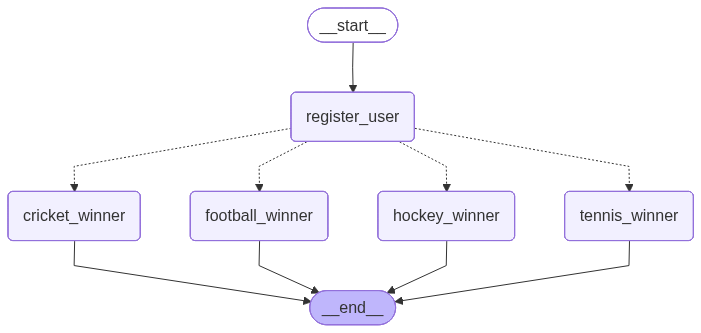

In [17]:
import os
from dotenv import load_dotenv
from langchain.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
from pydantic import BaseModel
from typing import Literal, Optional
import random
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

# loading environment variable
load_dotenv()

# Loading Groq api
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# loading model
llm_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Defining the State class
class State(BaseModel):
    user_name: str
    sport:Optional[Literal["cricket_winner", "football_winner", "hockey_winner", "tennis_winner"]] = None
    winner: Optional[str] = None


# Defining Nodes
def register_user(state:State):
    print("Registering the user.....")
    return{"user_name": state.user_name}

def cricket_winner(state:State):
    print("Checking for cricket winner.....")
    return {
        "sport": "cricket",
        "winner": llm_model.invoke(f"who won the last world cup in cricket").content
    }

def football_winner(state:State):
    print("Checking for football winner.....")
    return {
        "sport": "football",
        "winner": llm_model.invoke(f"who won the last world cup in football").content
    }

def hockey_winner(state:State):
    print("Checking for hockey winner.....")
    return {
        "sport": "hockey",
        "winner": llm_model.invoke(f"who won the last world cup in hockey").content
    }

def tennis_winner(state:State):
    print("Checking for tennis winner.....")
    return {
        "sport": "tennis",
        "winner": llm_model.invoke(f"who won the latest Wimbledon men's singles title").content
    }

# Defining condition
def select_sport(state:State) -> Literal["cricket_winner", "football_winner", "hockey_winner", "tennis_winner"]:
    random_number = random.random()
    if random_number > 0 and random_number < 0.25:
        return "cricket_winner"
    elif random_number >= 0.25 and random_number < 0.50:
        return "football_winner"
    elif random_number >= 0.50 and random_number < 0.75:
        return "hockey_winner"
    else:
        return "tennis_winner"
    
# Constructing the graph
graph = StateGraph(State)

graph.add_node("register_user", register_user)
graph.add_node("cricket_winner", cricket_winner)
graph.add_node("football_winner", football_winner)
graph.add_node("hockey_winner", hockey_winner)
graph.add_node("tennis_winner", tennis_winner)

graph.add_edge(START, "register_user")
graph.add_conditional_edges("register_user", select_sport)
graph.add_edge("cricket_winner", END)
graph.add_edge("football_winner", END)
graph.add_edge("hockey_winner", END)
graph.add_edge("tennis_winner", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [23]:
graph_builder.invoke({"user_name":"Abhishek"})

Registering the user.....
Checking for tennis winner.....


{'user_name': 'Abhishek',
 'sport': 'tennis',
 'winner': "The latest Wimbledon men's singles title was won by Carlos Alcaraz in 2023, but I'm not sure if that information is up to date as my knowledge cutoff is December 2023. For the most recent information, I recommend checking the official Wimbledon website or other reliable sources."}

### Chains

In [10]:
from langchain.messages import AIMessage, HumanMessage
from pprint import pprint
from langchain_groq import ChatGroq

# Messages List
messages = [HumanMessage(content="Hello")]
messages.append(AIMessage(content="Hello, How can I help you"))
messages.append(HumanMessage(content="I want to know about python"))

# model definition
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

# invoking model
messages.append(model.invoke(messages))

# displaying messages with formatting
for message in messages:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello, How can I help you
================================ Human Message =================================

I want to know about python
================================== Ai Message ==================================

**Introduction to Python**

Python is a high-level, interpreted programming language that is widely used for various purposes such as web development, scientific computing, data analysis, artificial intelligence, and more. It was created in the late 1980s by Guido van Rossum and was first released in 1991.

**Key Features of Python**
-------------------------

* **Easy to learn**: Python has a simple syntax and is relatively easy to learn, making it a great language for beginners.
* **High-level language**: Python is a high-level language, meaning it abstracts away many low-level details, allowing you to 

## Tools and ToolNode

### Simple graph with LLM model

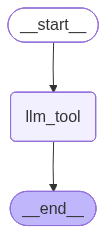

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add_numbers (98042kphm)
 Call ID: 98042kphm
  Args:
    a: 2
    b: 2


In [62]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages



# Add numbers tool
def add_numbers(a:int, b:int) -> int:
    """
    Funtion to add to numbers as return their result

    Args:
        a (int) : First number
        b (int) : second number

    Return:
        int: addtion of a and b
    """
    return a + b

# model definition
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

# State class with add_messages reducer to append all messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Node creation
def llm_tool(state:State):
    return {"messages": model_with_tools.invoke(state["messages"])}

# graph creation
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(State)

graph.add_node("llm_tool", llm_tool)

graph.add_edge(START, "llm_tool")
graph.add_edge("llm_tool", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))


# graph invocation
messages = graph_builder.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

### Tools and ToolNode with tool_condition

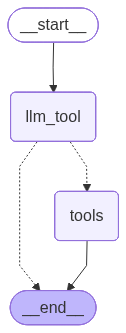

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add_numbers (g2svnf7dn)
 Call ID: g2svnf7dn
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add_numbers

4


In [67]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition



# Add numbers tool
def add_numbers(a:int, b:int) -> int:
    """
    Funtion to add to numbers as return their result

    Args:
        a (int) : First number
        b (int) : second number

    Return:
        int: addtion of a and b
    """
    return a + b

# model definition
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

# Binding the tool with llm model
model_with_tools = model.bind_tools(tools=[add_numbers])

# State class with add_messages reducer to append all messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Node creation
def llm_tool(state:State):
    return {"messages": model_with_tools.invoke(state["messages"])}

# list of tools
tools = [add_numbers]

# graph creation
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(State)

graph.add_node("llm_tool", llm_tool)
graph.add_node("tools", ToolNode(tools=tools))

graph.add_edge(START, "llm_tool")
graph.add_conditional_edges(
    "llm_tool",
    tools_condition
)
graph.add_edge("tools", END)
graph.add_edge("llm_tool", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))


# graph invocation
messages = graph_builder.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()